# AI-READI Dataset — Survey & Questionnaire Deep Dive

**Purpose**: Load the full observation.csv (2,280 patients) directly from Azure Blob Storage, profile all survey/questionnaire instruments, engineer composite ML features, and correlate them with CGM outcomes.

**Runtime**: Designed for Cursor IDE with a Colab kernel. Imports credentials from `config/azure_config.py` on the local filesystem — no extra setup needed.

**Outputs**: `data/processed/survey_features.csv` — a per-patient feature table ready to join the EDA merged dataset for ML.

---

**Table of Contents**
1. [Environment Setup](#1-environment-setup)
2. [Azure Connection & Data Load](#2-azure-connection--data-load)
3. [Item Key Parsing & Instrument Catalog](#3-item-key-parsing--instrument-catalog)
4. [Special Code Handling](#4-special-code-handling)
5. [Reusable Pivot Helper](#5-reusable-pivot-helper)
6. [CES-D-10 — Depression Screening](#6-ces-d-10--depression-screening)
7. [PAID-5 — Diabetes Distress](#7-paid-5--diabetes-distress)
8. [Diet & Self-Management Radar Chart](#8-diet--self-management-radar-chart)
9. [Comorbidity Index](#9-comorbidity-index)
10. [PhenX SDOH — PCA on Social Risk](#10-phenx-sdoh--pca-on-social-risk)
11. [Substance Use & OTC Medications](#11-substance-use--otc-medications)
12. [Family & Genetic Risk](#12-family--genetic-risk)
13. [Composite Feature Engineering](#13-composite-feature-engineering)
14. [Merge & Correlation with CGM Outcomes](#14-merge--correlation-with-cgm-outcomes)
15. [Missing Data Strategy](#15-missing-data-strategy)
16. [Key Findings & Feature Recommendations](#16-key-findings--feature-recommendations)

---

**Survey instruments covered**

| Instrument | Items | Aggregation |
|---|---|---|
| CES-D-10 (depression) | 10 | Sum → total score (0–30) |
| PAID-5 (diabetes distress) | 5 | Raw item sum (0–20); cutoff ≥8 |
| Diet survey | 9 | Precomputed diet score |
| Diabetes self-management | 10 | Domain means (5 domains); 3-level ordinal {0,5,10} |
| Medical history comorbidities | 29 binary + 1 count | Weighted comorbidity index + `n_falls` separately |
| Family history of T2D | 2 | Binary OR flag |
| PhenX SDOH / discrimination | 53 total; ~36 full-cohort used for PCA | PCA → 3 components |
| PhenX neighborhood | 18 | Subscale mean → `neighborhood_score` |
| Substance use | 26 (kncf binary subset used) | `kncf` ever-used count only |
| OTC medications | 6 | Usage burden sum (99→NaN) |

---

## 1. Environment Setup

In [22]:
import subprocess, sys

# Install any missing packages silently
packages = ['azure-storage-blob', 'plotly']
for pkg in packages:
    result = subprocess.run(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        capture_output=True, text=True
    )

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from io import StringIO
from pathlib import Path
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.3f}'.format)

print('Environment ready.')

Environment ready.


## 2. Azure Connection & Data Load

Imports credentials from `config/azure_config.py` (local filesystem via Cursor + Colab kernel).
Streams `observation.csv` (~108 MB) and `participants.tsv` directly from Azure Blob Storage.

In [23]:
import sys, os, getpass

# ── Detect runtime ──────────────────────────────────────────────────────────
IN_COLAB = os.path.exists('/content')

if IN_COLAB:
    # Colab cloud: prompt securely (input is masked, not stored in output)
    print('Paste your Azure CONNECTION_STRING when prompted (from config/azure_config.py):')
    CONNECTION_STRING = getpass.getpass('CONNECTION_STRING: ')
    CONTAINER_NAME    = 'aireadi-raw'
    print('✓ Credentials set')
else:
    # Local kernel (plain Jupyter, etc.)
    repo_root = os.path.abspath('..')
    if repo_root not in sys.path:
        sys.path.insert(0, repo_root)
    from config.azure_config import CONNECTION_STRING, CONTAINER_NAME
    print('✓ Credentials loaded from local config/azure_config.py')

from azure.storage.blob import BlobServiceClient
from io import StringIO
import pandas as pd

STUDY_ID = '00b62456-0b93-4975-a992-42ba6a50ed5c'

blob_service = BlobServiceClient.from_connection_string(CONNECTION_STRING)
container    = blob_service.get_container_client(CONTAINER_NAME)

def load_blob_csv(blob_path, sep=',', **kwargs):
    """Stream a CSV from Azure Blob directly into a DataFrame."""
    blob_client = container.get_blob_client(blob_path)
    data = blob_client.download_blob().readall().decode('utf-8')
    return pd.read_csv(StringIO(data), sep=sep, low_memory=False, **kwargs)

print('Connecting to Azure Blob Storage...')
print('Loading observation.csv (~108 MB)...')
obs_df = load_blob_csv(f'{STUDY_ID}/dataset/clinical_data/observation.csv')

print('Loading participants.tsv...')
participants = load_blob_csv(f'{STUDY_ID}/dataset/participants.tsv', sep='\t')

print()
print(f'Observation table : {len(obs_df):>8,} rows | {obs_df["person_id"].nunique():,} unique patients')
print(f'Participants      : {len(participants):>8,} rows')
print()
print('Study group distribution (full cohort):')
print(participants['study_group'].value_counts().to_string())

Paste your Azure CONNECTION_STRING when prompted (from config/azure_config.py):
✓ Credentials set
Connecting to Azure Blob Storage...
Loading observation.csv (~108 MB)...
Loading participants.tsv...

Observation table :  707,126 rows | 2,280 unique patients
Participants      :    2,280 rows

Study group distribution (full cohort):
study_group
healthy                                                                776
oral_medication_and_or_non_insulin_injectable_medication_controlled    686
pre_diabetes_lifestyle_controlled                                      560
insulin_dependent                                                      258


## 3. Item Key Parsing & Instrument Catalog

The `observation_source_value` field encodes each item as `"item_key, Description text"`.  
We extract the key and classify every row into a survey instrument, retinal imaging flag, or administrative timestamp.

In [24]:
# Parse item key
obs_df['item_key'] = (
    obs_df['observation_source_value']
    .str.strip('"')
    .str.split(',', n=1)
    .str[0]
    .str.strip()
)

# Define instrument membership
INSTRUMENTS = {
    'CES-D-10 (depression)'        : [f'ces{i}' for i in range(1, 11)] + ['cestl'],
    'PAID-5 (diabetes distress)'   : ['paid_scrd', 'paid_dpr', 'paid_wr', 'paid_eng', 'paid_cml', 'paidscore'],
    'Diet survey'                  : [f'diet{i}' for i in range(1, 10)] + ['dietscore'],
    'Diabetes self-management'     : ['dmlact', 'dmlvex', 'dmlhex', 'dmlsugar', 'dmlgrain',
                                       'dmlpor', 'dmlfrveg', 'dmledu', 'dmlfeet', 'dmlmd'],
    'Medical history'              : [k for k in obs_df['item_key'].unique() if k.startswith('mhoccur')],
    'Family history'               : ['fh_dm2pt', 'fh_dm2sb'],
    'Visual impairment'            : [f'via{i}' for i in range(1, 7)],
    'Substance use'                : [k for k in obs_df['item_key'].unique() if k.startswith('su') and not k.endswith(('mpdat','mpts','startts'))],
    'OTC medications'              : ['cm_act', 'cm_ant', 'cm_asp', 'cm_dcg', 'cm_ibp', 'cm_slp'],
    'PhenX SDOH'                   : [k for k in obs_df['item_key'].unique() if k.startswith('pxrd') and not k.endswith(('mpdat','mpts','startts','dat'))],
}

# Build reverse map: item_key → instrument name
key_to_instrument = {}
for name, keys in INSTRUMENTS.items():
    for k in keys:
        key_to_instrument[k] = name

# Classify each row
def classify_row(key):
    if key in key_to_instrument:
        return key_to_instrument[key]
    if any(key.startswith(p) for p in ['rtci','rtei','rtfl','rtma','rtop','rtsm','rtso','rttr']):
        return 'Retinal imaging flag'
    if any(key.endswith(s) for s in ['mpdat','cmpts','startts','strtts','dat']) or key in ['visdat','studyid','eos_ds']:
        return 'Admin / timestamp'
    return 'Other'

obs_df['instrument'] = obs_df['item_key'].apply(classify_row)

# Catalog
n_total = obs_df['person_id'].nunique()
catalog_rows = []
for name, keys in INSTRUMENTS.items():
    mask = obs_df['item_key'].isin(keys)
    n_patients = obs_df[mask]['person_id'].nunique()
    n_items = obs_df[mask]['item_key'].nunique()
    catalog_rows.append({
        'Instrument': name,
        'Defined items': len(keys),
        'Items in data': n_items,
        'Patients with data': n_patients,
        'Coverage (%)': f'{n_patients / n_total * 100:.1f}%',
    })

catalog_df = pd.DataFrame(catalog_rows)
print('Survey Instrument Coverage (full cohort):')
display(catalog_df)

print(f'\nRow classification summary:')
print(obs_df['instrument'].value_counts().to_string())

Survey Instrument Coverage (full cohort):


,Instrument,Defined items,Items in data,Patients with data,Coverage (%)
0,CES-D-10 (depression),11,11,2279,100.0%
1,PAID-5 (diabetes distress),6,6,2229,97.8%
2,Diet survey,10,10,2203,96.6%
3,Diabetes self-management,10,10,2280,100.0%
4,Medical history,30,30,2280,100.0%
5,Family history,2,2,2280,100.0%
6,Visual impairment,6,6,2280,100.0%
7,Substance use,26,26,2280,100.0%
8,OTC medications,6,6,2233,97.9%
9,PhenX SDOH,53,53,2280,100.0%



Row classification summary:
instrument
Other                         181742
Admin / timestamp             120434
Retinal imaging flag           98931
PhenX SDOH                     97665
Medical history                66486
Substance use                  28875
CES-D-10 (depression)          24991
Diabetes self-management       22800
Diet survey                    21977
OTC medications                13388
PAID-5 (diabetes distress)     13345
Visual impairment              11932
Family history                  4560


## 4. Special Code Handling

OMOP clinical data uses reserved codes that are **not numeric values**:
- **555** = item was not asked / not applicable to this participant  
- **777** = participant refused or answered "don't know"

Both must be treated as `NaN` before any statistical computation.

In [25]:
SPECIAL_CODES = {555, 777, 555.0, 777.0}

n_special = obs_df['value_as_number'].isin(SPECIAL_CODES).sum()
print(f'Rows with special codes (555/777): {n_special:,} ({n_special/len(obs_df)*100:.1f}% of all rows)')

obs_df['value_clean'] = obs_df['value_as_number'].replace(
    {555: np.nan, 777: np.nan, 555.0: np.nan, 777.0: np.nan}
)

# Verify
remaining = obs_df['value_clean'].isin(SPECIAL_CODES).sum()
print(f'Remaining special codes after replacement: {remaining}')
print('✓ Special codes cleaned')

Rows with special codes (555/777): 5,182 (0.7% of all rows)
Remaining special codes after replacement: 0
✓ Special codes cleaned


## 5. Reusable Pivot Helper

All instrument sections use this single function to go from OMOP long format → per-patient wide format.

In [26]:
def pivot_instrument(df, item_keys, value_col='value_clean'):
    """
    Pivot OMOP long-format observations to wide format (one row per patient).
    Uses pivot_table (not pivot) to handle any duplicate person_id × item_key entries
    by taking the mean (appropriate for validated survey instruments).
    """
    # Filter to relevant item keys (only those present in data)
    present_keys = [k for k in item_keys if k in df['item_key'].values]
    if not present_keys:
        print(f'  Warning: none of the specified item keys found in data')
        return pd.DataFrame()

    long = df[df['item_key'].isin(present_keys)][['person_id', 'item_key', value_col]]
    wide = long.pivot_table(index='person_id', columns='item_key', values=value_col, aggfunc='mean')
    wide.columns.name = None  # Clean up MultiIndex artifact
    return wide

print('✓ pivot_instrument() defined')

✓ pivot_instrument() defined


## 6. CES-D-10 — Depression Screening

The **CES-D-10** is a 10-item validated scale (score range 0–30). **Cutoff ≥ 10** indicates probable depression.  
Items 5 and 8 are reverse-coded (stored pre-reversed in OMOP).  
Administered to all AI-READI participants regardless of diabetes status.

In [27]:
cesd_keys = [f'ces{i}' for i in range(1, 11)] + ['cestl']
cesd_wide = pivot_instrument(obs_df, cesd_keys)

print(f'CES-D-10 data available for {len(cesd_wide):,} patients ({len(cesd_wide)/obs_df["person_id"].nunique()*100:.1f}%)')

# Attach study group for stratification
group_map = participants.set_index('person_id')['study_group']
cesd_wide['study_group'] = cesd_wide.index.map(group_map)

if 'cestl' in cesd_wide.columns:
    total = cesd_wide['cestl'].dropna()
    print(f'\nCES-D-10 total score — full cohort:')
    print(f'  Mean  : {total.mean():.2f}')
    print(f'  Median: {total.median():.2f}')
    print(f'  Range : [{total.min():.0f}, {total.max():.0f}]')
    print(f'  At/above depression cutoff (≥10): {(total >= 10).sum():,} patients ({(total >= 10).mean()*100:.1f}%)')
    print()

    # By study group
    print('Depression rate (≥10) by study group:')
    for grp, grp_df in cesd_wide.groupby('study_group'):
        t = grp_df['cestl'].dropna()
        if len(t) > 0:
            pct = (t >= 10).mean() * 100
            print(f'  {grp[:50]:<50}: {pct:.1f}% (N={len(t):,})')

CES-D-10 data available for 2,279 patients (100.0%)

CES-D-10 total score — full cohort:
  Mean  : 5.85
  Median: 5.00
  Range : [0, 30]
  At/above depression cutoff (≥10): 455 patients (20.0%)

Depression rate (≥10) by study group:
  healthy                                           : 15.7% (N=776)
  insulin_dependent                                 : 32.0% (N=256)
  oral_medication_and_or_non_insulin_injectable_medi: 19.4% (N=686)
  pre_diabetes_lifestyle_controlled                 : 21.1% (N=559)


/tmp/ipython-input-4073862984.py:9: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



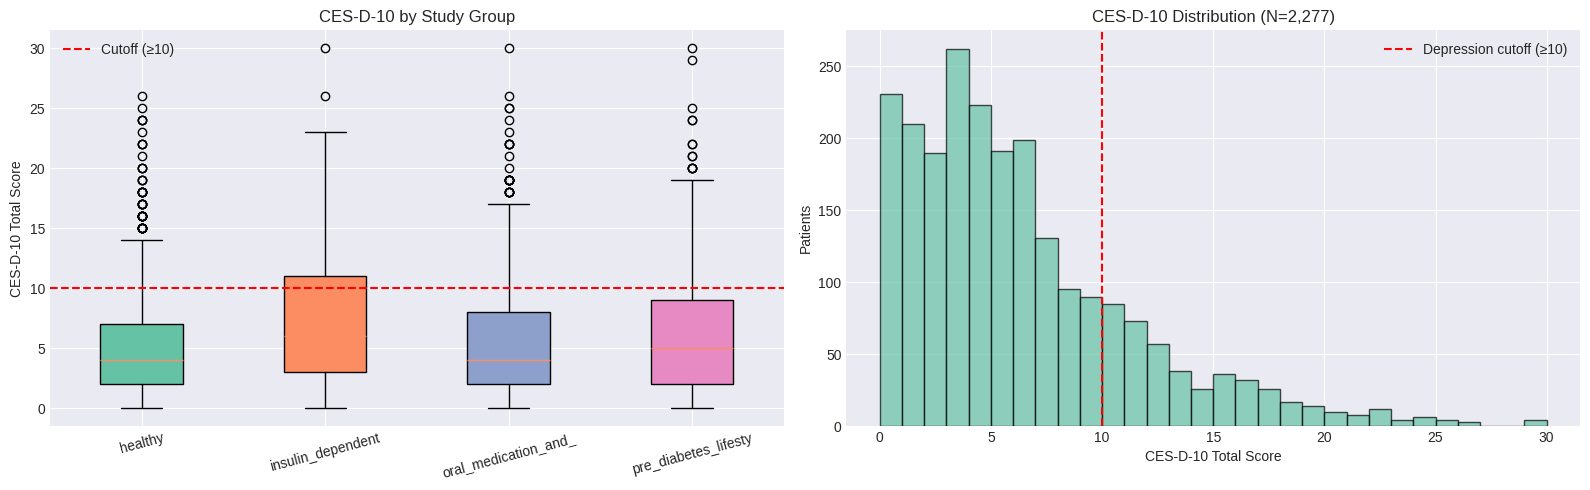

In [28]:
if 'cestl' in cesd_wide.columns and 'study_group' in cesd_wide.columns:
    plot_data = cesd_wide[['cestl', 'study_group']].dropna()

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    # Box plot by study group
    groups = sorted(plot_data['study_group'].unique())
    data_by_group = [plot_data[plot_data['study_group'] == g]['cestl'].values for g in groups]
    bp = axes[0].boxplot(data_by_group, labels=[g.split('(')[0].strip()[:20] for g in groups],
                          patch_artist=True)
    colors = sns.color_palette('Set2', len(groups))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    axes[0].axhline(10, color='red', linestyle='--', linewidth=1.5, label='Cutoff (≥10)')
    axes[0].set_ylabel('CES-D-10 Total Score')
    axes[0].set_title('CES-D-10 by Study Group')
    axes[0].legend()
    axes[0].tick_params(axis='x', rotation=15)

    # Overall distribution with cutoff
    axes[1].hist(plot_data['cestl'], bins=30, edgecolor='black', alpha=0.7)
    axes[1].axvline(10, color='red', linestyle='--', linewidth=1.5, label='Depression cutoff (≥10)')
    axes[1].set_xlabel('CES-D-10 Total Score')
    axes[1].set_ylabel('Patients')
    axes[1].set_title(f'CES-D-10 Distribution (N={len(plot_data):,})')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

## 7. PAID-5 — Diabetes Distress

The **PAID-5** (Problem Areas in Diabetes, 5-item) measures emotional distress related to diabetes management.  
Score range: **0–20** (raw item sum, 5 items × 0–4 each). **Cutoff ≥ 8** indicates high distress (equivalent to ≥40 on the 0–100 rescaled version).  
> Administered to **97.8% of the cohort** (2,229/2,280 patients) across all study groups — not limited to diabetes patients. Healthy controls may have low scores rather than NaN.

PAID-5 data available for 2,229 patients (97.8%)
(Administered across all study groups, not diabetes-only)

PAID-5 total score (raw item sum, 0–20):
  Mean  : 4.00
  Range : [0, 20]
  High distress (≥8, raw scale): 451 patients (20.2%)

High distress rate (≥8) by study group:
  healthy                                           : 12.9% (N=753)
  insulin_dependent                                 : 31.9% (N=254)
  oral_medication_and_or_non_insulin_injectable_medi: 20.6% (N=671)
  pre_diabetes_lifestyle_controlled                 : 24.5% (N=551)


/tmp/ipython-input-2761191470.py:32: MatplotlibDeprecationWarning:

The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.



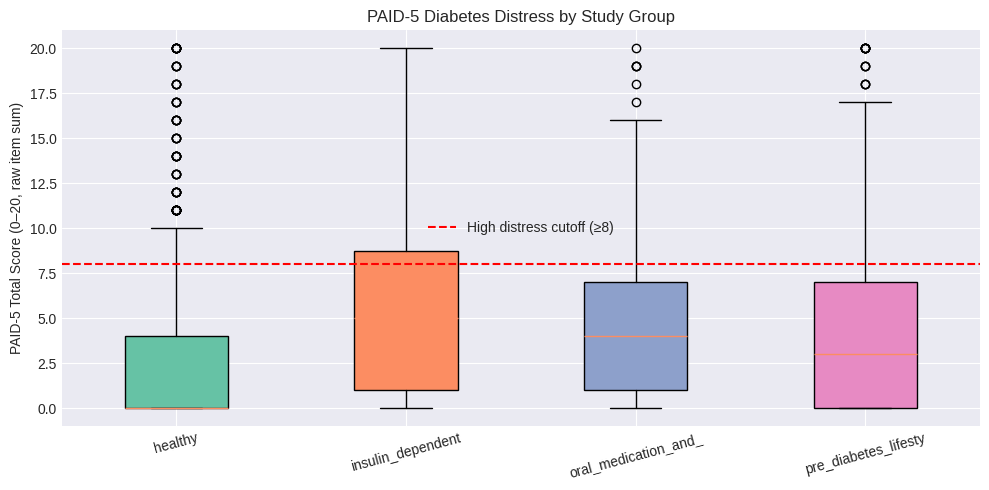

In [29]:
paid_keys = ['paid_scrd', 'paid_dpr', 'paid_wr', 'paid_eng', 'paid_cml', 'paidscore']
paid_wide = pivot_instrument(obs_df, paid_keys)

print(f'PAID-5 data available for {len(paid_wide):,} patients ({len(paid_wide)/obs_df["person_id"].nunique()*100:.1f}%)')
print('(Administered across all study groups, not diabetes-only)')

paid_wide['study_group'] = paid_wide.index.map(group_map)

# High distress cutoff: ≥8 on the 0–20 raw scale (≡ ≥40 on 0–100 rescaled)
PAID_DISTRESS_CUTOFF = 8

if 'paidscore' in paid_wide.columns:
    total = paid_wide['paidscore'].dropna()
    print(f'\nPAID-5 total score (raw item sum, 0–20):')
    print(f'  Mean  : {total.mean():.2f}')
    print(f'  Range : [{total.min():.0f}, {total.max():.0f}]')
    print(f'  High distress (≥{PAID_DISTRESS_CUTOFF}, raw scale): {(total >= PAID_DISTRESS_CUTOFF).sum():,} patients ({(total >= PAID_DISTRESS_CUTOFF).mean()*100:.1f}%)')

    print(f'\nHigh distress rate (≥{PAID_DISTRESS_CUTOFF}) by study group:')
    for grp, grp_df in paid_wide[paid_wide['study_group'].notna()].groupby('study_group'):
        t = grp_df['paidscore'].dropna()
        if len(t) > 0:
            pct = (t >= PAID_DISTRESS_CUTOFF).mean() * 100
            print(f'  {grp[:50]:<50}: {pct:.1f}% (N={len(t):,})')

    # Box plot
    non_null = paid_wide[paid_wide['paidscore'].notna() & paid_wide['study_group'].notna()]
    groups = sorted(non_null['study_group'].unique())
    data_by_group = [non_null[non_null['study_group'] == g]['paidscore'].values for g in groups]

    fig, ax = plt.subplots(figsize=(10, 5))
    bp = ax.boxplot(data_by_group, labels=[g.split('(')[0].strip()[:20] for g in groups], patch_artist=True)
    colors = sns.color_palette('Set2', len(groups))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
    ax.axhline(PAID_DISTRESS_CUTOFF, color='red', linestyle='--', linewidth=1.5,
               label=f'High distress cutoff (≥{PAID_DISTRESS_CUTOFF})')
    ax.set_ylabel('PAID-5 Total Score (0–20, raw item sum)')
    ax.set_title('PAID-5 Diabetes Distress by Study Group')
    ax.legend()
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.show()

## 8. Diet & Self-Management Radar Chart

**Diet survey** (9 items → `dietscore`): overall dietary quality.  
**Diabetes self-management (DML)**: 5 behavioral domains — physical activity, diet adherence, education, foot care, medication management.

> **Note on DML scale**: DML items are stored as a **3-level ordinal {0, 5, 10}**, not a continuous 0–10 scale. Domain means will produce values in the set {0, 2.5, 3.33, 5, 6.67, 7.5, 10}. This is expected and valid for visualization and feature engineering — just treat domain scores as ordinal in tree-based models.

The radar chart is the most informative visualization here: it reveals which groups are deficient in which self-management domains simultaneously.

In [30]:
# Diet survey
diet_keys = [f'diet{i}' for i in range(1, 10)] + ['dietscore']
diet_wide = pivot_instrument(obs_df, diet_keys)
diet_wide['study_group'] = diet_wide.index.map(group_map)

# Diabetes self-management domains
DML_DOMAINS = {
    'Physical activity' : ['dmlact', 'dmlvex', 'dmlhex'],
    'Diet adherence'    : ['dmlsugar', 'dmlgrain', 'dmlpor', 'dmlfrveg'],
    'Education'         : ['dmledu'],
    'Foot care'         : ['dmlfeet'],
    'Medication mgmt'   : ['dmlmd'],
}

dml_all_keys = [k for keys in DML_DOMAINS.values() for k in keys]
dml_wide = pivot_instrument(obs_df, dml_all_keys)
dml_wide['study_group'] = dml_wide.index.map(group_map)

print(f'Diet data    : {diet_wide.dropna(subset=["dietscore"] if "dietscore" in diet_wide.columns else []).shape[0]:,} patients')
print(f'DML data     : {len(dml_wide):,} patients')

# Compute domain scores per patient
for domain, keys in DML_DOMAINS.items():
    present = [k for k in keys if k in dml_wide.columns]
    if present:
        dml_wide[f'domain_{domain.lower().replace(" ","_")}'] = dml_wide[present].mean(axis=1)

Diet data    : 727 patients
DML data     : 2,280 patients


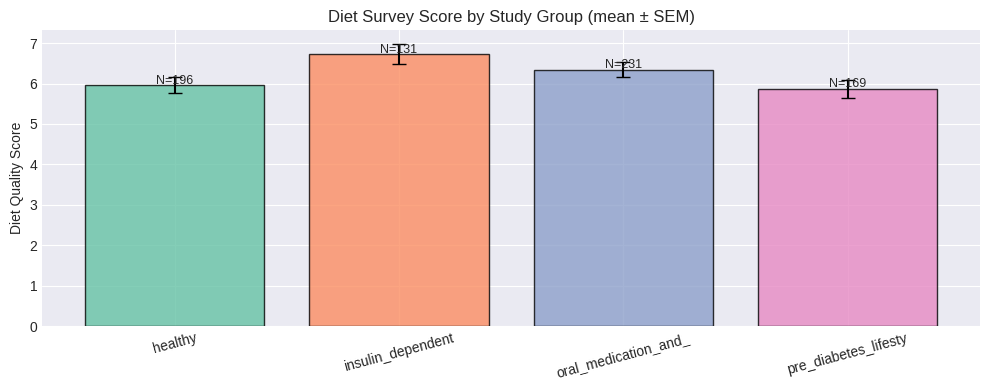

In [31]:
# Radar chart — mean domain score per study group
domain_cols = [f'domain_{d.lower().replace(" ","_")}' for d in DML_DOMAINS.keys()]
domain_cols_present = [c for c in domain_cols if c in dml_wide.columns]
domain_labels = [d for d, c in zip(DML_DOMAINS.keys(), domain_cols) if c in dml_wide.columns]

if domain_cols_present and 'study_group' in dml_wide.columns:
    group_means = dml_wide.groupby('study_group')[domain_cols_present].mean()

    fig = go.Figure()
    colors_radar = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

    for i, (grp, row) in enumerate(group_means.iterrows()):
        values = row.values.tolist()
        values_closed = values + [values[0]]  # Close the polygon
        labels_closed = domain_labels + [domain_labels[0]]

        fig.add_trace(go.Scatterpolar(
            r=values_closed,
            theta=labels_closed,
            fill='toself',
            opacity=0.4,
            name=grp.split('(')[0].strip()[:30],
            line=dict(color=colors_radar[i % len(colors_radar)], width=2),
        ))

    fig.update_layout(
        polar=dict(radialaxis=dict(visible=True, range=[0, 10])),
        title='Diabetes Self-Management Domain Profiles by Study Group<br><sup>Higher = better self-management (scale 0–10)</sup>',
        legend=dict(orientation='h', yanchor='bottom', y=-0.2),
        width=650, height=550,
    )
    fig.show()

    # Also show diet score comparison
    if 'dietscore' in diet_wide.columns:
        diet_grp = diet_wide.groupby('study_group')['dietscore'].agg(['mean','sem','count']).reset_index()
        fig2, ax = plt.subplots(figsize=(10, 4))
        colors = sns.color_palette('Set2', len(diet_grp))
        bars = ax.bar(diet_grp['study_group'].str[:20], diet_grp['mean'],
                      yerr=diet_grp['sem'], capsize=5, edgecolor='black', alpha=0.8, color=colors)
        for bar, row in zip(bars, diet_grp.itertuples()):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + diet_grp['sem'].max()*0.15,
                    f'N={row.count:,}', ha='center', fontsize=9)
        ax.set_ylabel('Diet Quality Score')
        ax.set_title('Diet Survey Score by Study Group (mean ± SEM)')
        ax.tick_params(axis='x', rotation=15)
        plt.tight_layout()
        plt.show()
else:
    print('Insufficient DML data for radar chart in this dataset.')

## 9. Comorbidity Index

Medical history (`mhoccur_*`) provides 30 comorbidity items — **29 are binary flags** (0=absent, 1=present); **`mhoccur_fallot` is a fall count** (continuous, N=367 in cohort) and is treated separately as `n_falls`.  
We construct a **weighted comorbidity index** from the 29 binary items based on clinical severity/mortality impact —  
inspired by the Charlson Comorbidity Index but adapted for the AI-READI condition set.

In [32]:
mh_keys = [k for k in obs_df['item_key'].unique() if k.startswith('mhoccur')]
mh_wide = pivot_instrument(obs_df, mh_keys)
mh_wide['study_group'] = mh_wide.index.map(group_map)

print(f'Medical history data: {len(mh_wide):,} patients')
print(f'Comorbidity items   : {len(mh_keys)}')

# mhoccur_fallot is a count (not binary) — extract separately before building index
if 'mhoccur_fallot' in mh_wide.columns:
    mh_wide['n_falls'] = mh_wide['mhoccur_fallot'].clip(upper=20)  # cap implausible values
    print(f"\nn_falls (fall count, separate from binary index):")
    print(f"  mean={mh_wide['n_falls'].mean():.2f}, N={mh_wide['n_falls'].notna().sum()}")

# Binary items only (exclude fallot from index)
BINARY_EXCLUSIONS = {'mhoccur_fallot'}

# Weighted comorbidity index — binary items only
COMORBIDITY_WEIGHTS = {
    # High weight (mortality/morbidity risk)
    'mhoccur_mi'   : 2,  # Myocardial infarction
    'mhoccur_strk' : 2,  # Stroke
    'mhoccur_rnl'  : 2,  # Renal disease
    'mhoccur_ca'   : 2,  # Cancer
    'mhoccur_pd'   : 2,  # Parkinson disease
    'mhoccur_ad'   : 2,  # Alzheimer disease
    'mhoccur_ms'   : 2,  # Multiple sclerosis
    'mhoccur_pdr'  : 2,  # Proliferative diabetic retinopathy (severe diabetes complication)
    # Moderate weight
    'mhoccur_hbp'  : 1,  # Hypertension
    'mhoccur_clsh' : 1,  # High cholesterol
    'mhoccur_obs'  : 1,  # Obesity
    'mhoccur_cvdot': 1,  # Other CVD
    'mhoccur_cogn' : 1,  # Cognitive impairment
    'mhoccur_glc'  : 1,  # Glaucoma
    'mhoccur_amd'  : 1,  # AMD
    'mhoccur_oa'   : 1,  # Osteoarthritis
    'mhoccur_ra'   : 1,  # Rheumatoid arthritis
    'mhoccur_lbp'  : 1,  # Low back pain
    'mhoccur_plm'  : 1,  # Pulmonary disease
    'mhoccur_gi'   : 1,  # GI disorder
    'mhoccur_ear'  : 1,  # Hearing impairment
    'mhoccur_ua'   : 1,  # Urinary/bladder
    'mhoccur_crt'  : 1,  # Cataracts
    'mhoccur_rvo'  : 1,  # Retinal vascular occlusion
    'mhoccur_circ' : 1,  # Circulatory disorder
    'mhoccur_cns'  : 1,  # Other CNS
}

# Compute index per patient
weighted_scores = pd.Series(0.0, index=mh_wide.index)
for col, weight in COMORBIDITY_WEIGHTS.items():
    if col in mh_wide.columns:
        weighted_scores += mh_wide[col].fillna(0) * weight

mh_wide['comorbidity_index'] = weighted_scores

print(f'\nComorbidity index (29 binary items) — full cohort:')
print(f'  Mean   : {weighted_scores.mean():.2f}')
print(f'  Median : {weighted_scores.median():.2f}')
print(f'  Max    : {weighted_scores.max():.2f}')
print(f'  Zero (no comorbidities): {(weighted_scores == 0).sum():,} patients')

print('\nComorbidity prevalence (top 15 binary items):')
# Exclude mhoccur_fallot from prevalence display (it is a count, not binary)
item_cols = [c for c in mh_wide.columns if c.startswith('mhoccur') and c not in BINARY_EXCLUSIONS]
prevalence = mh_wide[item_cols].mean().sort_values(ascending=False).head(15)
condition_labels = {
    'mhoccur_hbp':'Hypertension', 'mhoccur_clsh':'High cholesterol', 'mhoccur_obs':'Obesity',
    'mhoccur_crt':'Cataracts', 'mhoccur_ded':'Dry eye', 'mhoccur_glc':'Glaucoma',
    'mhoccur_amd':'AMD', 'mhoccur_pdr':'Diabetic retinopathy', 'mhoccur_oa':'Osteoarthritis',
    'mhoccur_lbp':'Low back pain', 'mhoccur_ear':'Hearing impairment', 'mhoccur_gi':'GI disorder',
    'mhoccur_ca':'Cancer', 'mhoccur_mi':'MI', 'mhoccur_strk':'Stroke', 'mhoccur_ra':'Rheumatoid arthritis',
    'mhoccur_rvo':'Retinal vascular occlusion', 'mhoccur_ua':'Urinary disorder',
    'mhoccur_cogn':'Cognitive impairment', 'mhoccur_rnl':'Renal disease',
}
labeled_prev = prevalence.rename(lambda x: condition_labels.get(x, x))
print(labeled_prev.to_string())

Medical history data: 2,280 patients
Comorbidity items   : 30

n_falls (fall count, separate from binary index):
  mean=2.14, N=367

Comorbidity index (29 binary items) — full cohort:
  Mean   : 4.38
  Median : 4.00
  Max    : 18.00
  Zero (no comorbidities): 177 patients

Comorbidity prevalence (top 15 binary items):
High cholesterol       0.506
Hypertension           0.506
Rheumatoid arthritis   0.415
Obesity                0.376
Dry eye                0.326
Cataracts              0.304
mhoccur_yn             0.245
Urinary disorder       0.228
GI disorder            0.227
Cancer                 0.177
mhoccur_fall           0.166
Hearing impairment     0.146
mhoccur_cvdot          0.139
mhoccur_plm            0.133
Osteoarthritis         0.128


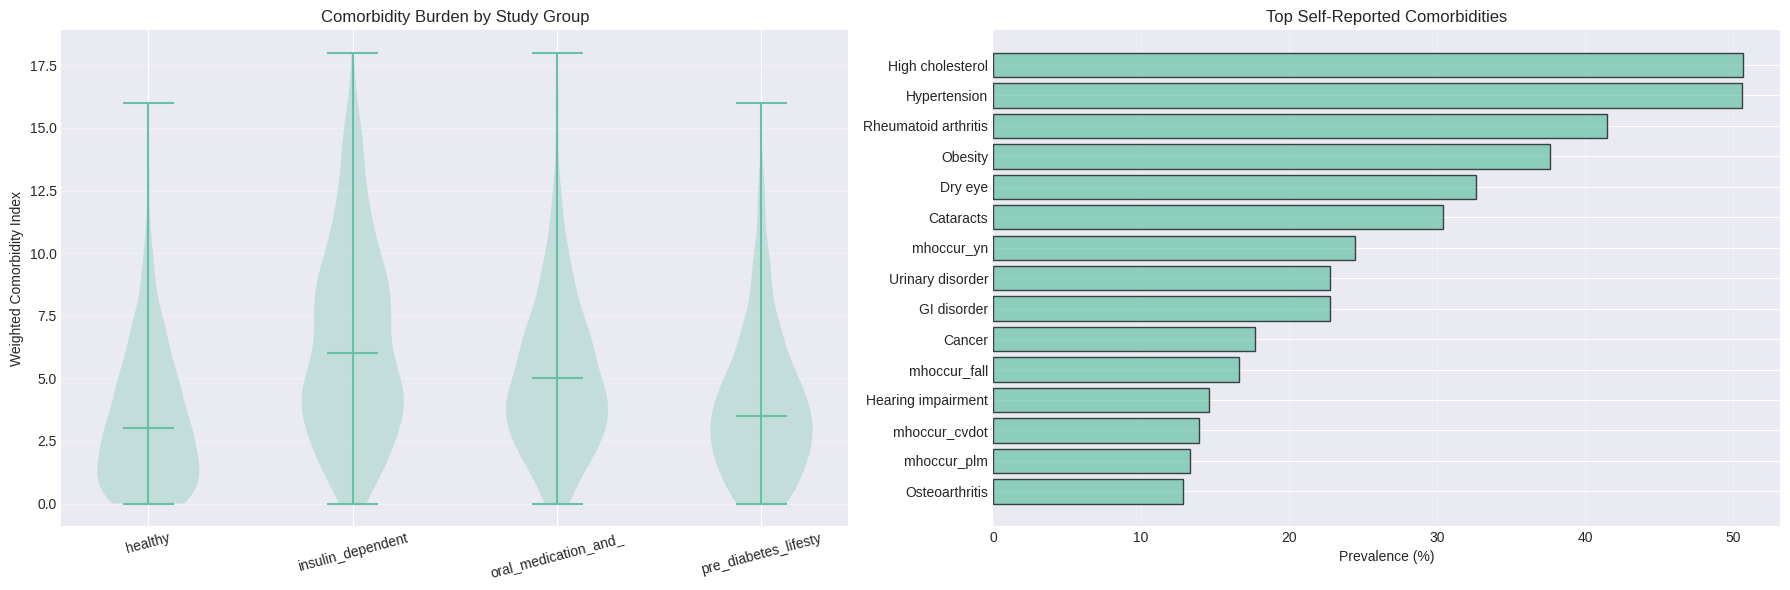

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.

/usr/local/lib/python3.12/dist-packages/seaborn/matrix.py:560: UserWarning:

Clustering large matrix with scipy. Installing `fastcluster` may give better performance.



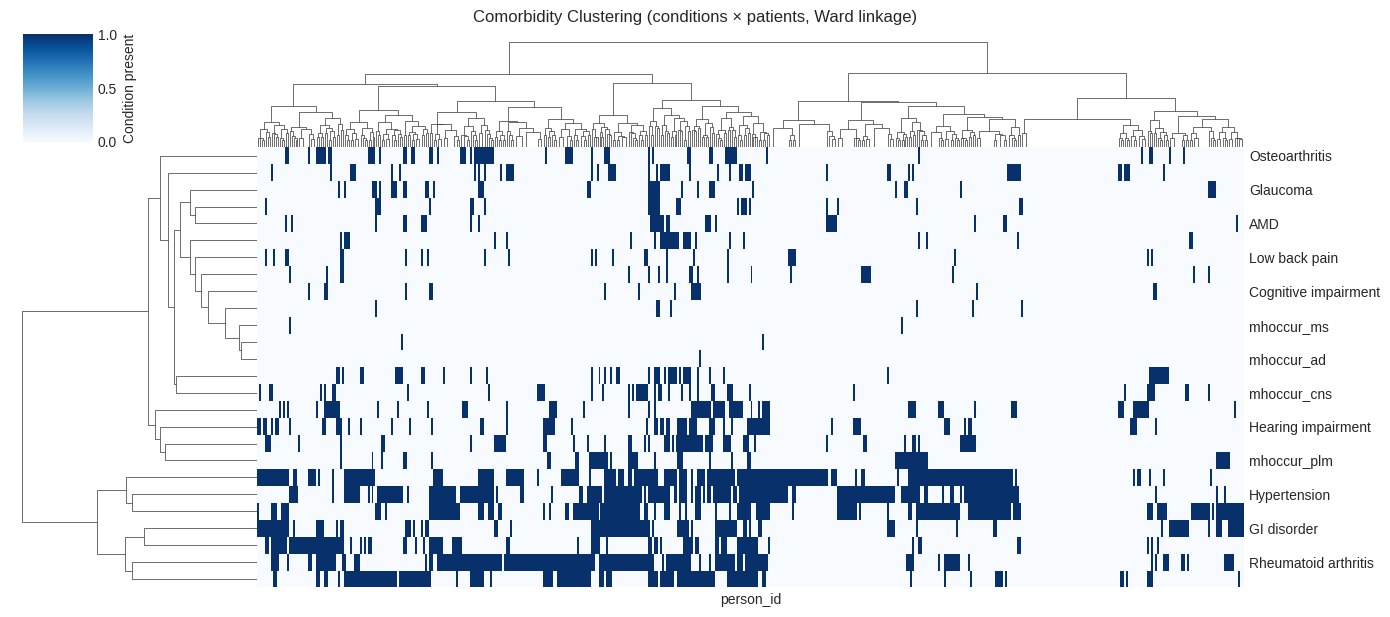

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Comorbidity index by study group
if 'study_group' in mh_wide.columns:
    groups = sorted(mh_wide['study_group'].dropna().unique())
    data_by_group = [mh_wide[mh_wide['study_group'] == g]['comorbidity_index'].values for g in groups]
    bp = axes[0].violinplot(data_by_group, positions=range(len(groups)), showmedians=True)
    axes[0].set_xticks(range(len(groups)))
    axes[0].set_xticklabels([g.split('(')[0].strip()[:20] for g in groups], rotation=15)
    axes[0].set_ylabel('Weighted Comorbidity Index')
    axes[0].set_title('Comorbidity Burden by Study Group')
    axes[0].grid(axis='y', alpha=0.3)

# Top comorbidities prevalence bar chart
nonzero = labeled_prev[labeled_prev > 0].sort_values()
axes[1].barh(nonzero.index, nonzero.values * 100, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Prevalence (%)')
axes[1].set_title('Top Self-Reported Comorbidities')
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Clustered heatmap (patient × comorbidity)
item_cols_present = [c for c in COMORBIDITY_WEIGHTS.keys() if c in mh_wide.columns]
if len(item_cols_present) >= 5 and len(mh_wide) >= 10:
    heatmap_data = mh_wide[item_cols_present].fillna(0)
    # Subsample if very large (clustermap is slow for N>500)
    if len(heatmap_data) > 500:
        heatmap_data = heatmap_data.sample(500, random_state=42)

    col_labels = [condition_labels.get(c, c) for c in item_cols_present]
    heatmap_data.columns = col_labels

    g = sns.clustermap(
        heatmap_data.T,  # Conditions on y-axis, patients on x-axis
        method='ward', cmap='Blues',
        figsize=(14, 6), xticklabels=False,
        cbar_kws={'label': 'Condition present'}
    )
    g.fig.suptitle('Comorbidity Clustering (conditions × patients, Ward linkage)', y=1.02)
    plt.show()

## 10. PhenX SDOH — PCA on Social Risk

The **PhenX discrimination & adversity scale** (`pxrd1`–`pxrd53`) covers: education, employment, housing stability, food security, racial/ethnic/gender/age discrimination, healthcare access, and neighborhood environment.  

**Important data characteristics (confirmed by full-cohort probe):**
- Values are **1-based Likert** (min=1, max=6) — StandardScaler will center and normalize these before PCA.
- ~36 items are **full-cohort** (N≈2,240); ~17 items are **skip-gated** (N=510–1,382) due to conditional branching.
- **PCA uses only full-cohort items** to avoid imputing >40% of the feature matrix for skip-gated items.

PhenX SDOH item keys found in data: 92
Patients with any SDOH data: 2,280

Full-cohort pxrd items (N≥1800): 72
Skip-gated pxrd items  (N< 1800): 20 — excluded from PCA
PCA will use full-cohort items only.


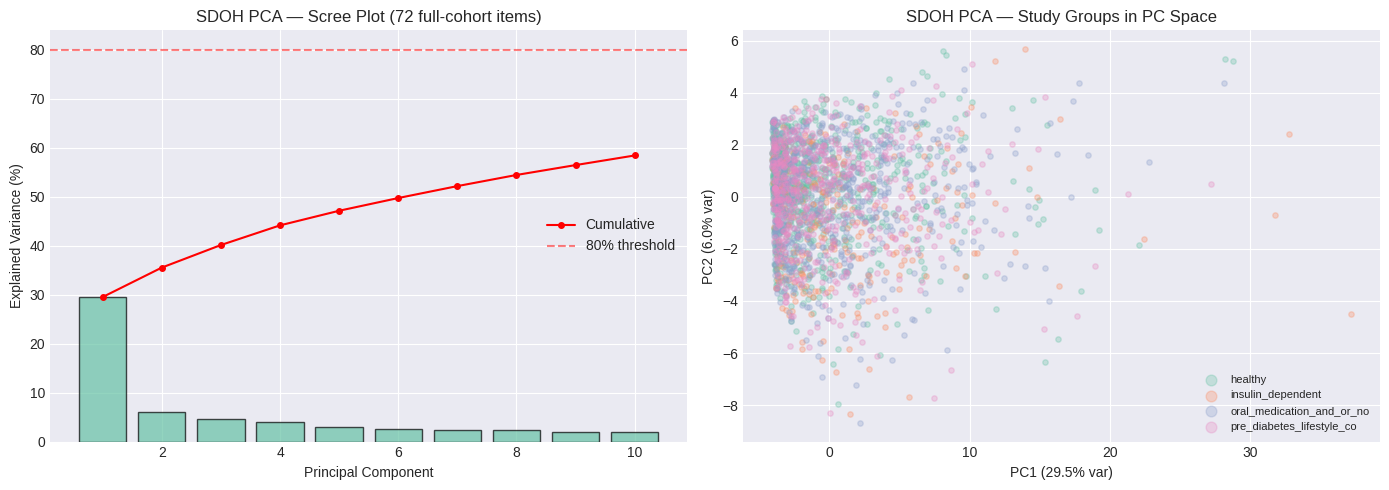


Top 5 items by PC1 loading (absolute value):
pxrd17   0.172
pxrd8    0.170
pxrd5    0.170
pxrd38   0.169
pxrd23   0.168

Top 5 items by PC2 loading:
pxne14   0.323
pxne17   0.318
pxne9    0.314
pxne6    0.299
pxne13   0.298


In [34]:
# All pxrd* item keys (response items only, not metadata)
sdoh_keys = [k for k in obs_df['item_key'].unique()
             if k.startswith('pxrd') and not any(k.endswith(s) for s in ['mpdat','cmpts','startts','dat'])]
# Also include other PhenX subscales if present
sdoh_keys += [k for k in obs_df['item_key'].unique()
              if any(k.startswith(p) for p in ['pxfi', 'pxne', 'pxahc', 'pxdhc'])
              and not any(k.endswith(s) for s in ['mpdat','cmpts','startts','dat'])]

sdoh_keys = list(set(sdoh_keys))  # Deduplicate
print(f'PhenX SDOH item keys found in data: {len(sdoh_keys)}')

sdoh_wide = pivot_instrument(obs_df, sdoh_keys)
print(f'Patients with any SDOH data: {len(sdoh_wide):,}')

# Split full-cohort vs skip-gated items based on per-item coverage
# PCA runs only on full-cohort items to avoid imputing sparse columns
FULL_COHORT_THRESHOLD = 1800  # ~80% of 2,280
item_coverage = sdoh_wide.notna().sum()
full_cohort_items = item_coverage[item_coverage >= FULL_COHORT_THRESHOLD].index.tolist()
skip_gated_items  = item_coverage[item_coverage <  FULL_COHORT_THRESHOLD].index.tolist()

print(f'\nFull-cohort pxrd items (N≥{FULL_COHORT_THRESHOLD}): {len(full_cohort_items)}')
print(f'Skip-gated pxrd items  (N< {FULL_COHORT_THRESHOLD}): {len(skip_gated_items)} — excluded from PCA')
print('PCA will use full-cohort items only.')

sdoh_numeric = sdoh_wide[full_cohort_items].copy()

if len(sdoh_numeric) > 10 and len(full_cohort_items) > 3:
    # Impute missing with column median before PCA
    for col in sdoh_numeric.columns:
        sdoh_numeric[col] = sdoh_numeric[col].fillna(sdoh_numeric[col].median())

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(sdoh_numeric)

    n_components = min(10, len(full_cohort_items), len(sdoh_wide) - 1)
    pca = PCA(n_components=n_components, random_state=42)
    scores = pca.fit_transform(X_scaled)

    explained = pca.explained_variance_ratio_
    cumulative = np.cumsum(explained)

    # Scree plot
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(range(1, len(explained)+1), explained * 100, edgecolor='black', alpha=0.7)
    axes[0].plot(range(1, len(cumulative)+1), cumulative * 100, 'r-o', markersize=4, label='Cumulative')
    axes[0].axhline(80, color='red', linestyle='--', alpha=0.5, label='80% threshold')
    axes[0].set_xlabel('Principal Component')
    axes[0].set_ylabel('Explained Variance (%)')
    axes[0].set_title(f'SDOH PCA — Scree Plot ({len(full_cohort_items)} full-cohort items)')
    axes[0].legend()

    # PC1 vs PC2 scatter colored by study group
    sdoh_scores_df = pd.DataFrame(scores[:, :3], index=sdoh_wide.index,
                                   columns=['PC1', 'PC2', 'PC3'])
    sdoh_scores_df['study_group'] = sdoh_scores_df.index.map(group_map)

    for grp, color in zip(sorted(sdoh_scores_df['study_group'].dropna().unique()),
                           sns.color_palette('Set2')):
        mask = sdoh_scores_df['study_group'] == grp
        axes[1].scatter(sdoh_scores_df[mask]['PC1'], sdoh_scores_df[mask]['PC2'],
                        alpha=0.3, s=15, label=grp.split('(')[0].strip()[:25], color=color)

    axes[1].set_xlabel(f'PC1 ({explained[0]*100:.1f}% var)')
    axes[1].set_ylabel(f'PC2 ({explained[1]*100:.1f}% var)')
    axes[1].set_title('SDOH PCA — Study Groups in PC Space')
    axes[1].legend(fontsize=8, markerscale=2)

    plt.tight_layout()
    plt.show()

    # Top loading items for PC1 and PC2
    loadings = pd.DataFrame(pca.components_[:3].T, index=full_cohort_items, columns=['PC1','PC2','PC3'])
    print('\nTop 5 items by PC1 loading (absolute value):')
    print(loadings['PC1'].abs().sort_values(ascending=False).head(5).to_string())
    print('\nTop 5 items by PC2 loading:')
    print(loadings['PC2'].abs().sort_values(ascending=False).head(5).to_string())

else:
    print('Insufficient SDOH item-level data in this dataset for PCA.')
    sdoh_scores_df = None
    pca = None

## 11. Substance Use & OTC Medications

**Substance use** (`su*`): alcohol, tobacco, cannabis, vaping — a heterogeneous mix of binary ever-used flags (`*kncf`), age-of-onset, duration, and frequency items.  
**Substance exposure score** uses only the binary `*kncf` (know/confirm) ever-used items to avoid mixing flag counts with continuous age/duration measures.

**OTC medications** (`cm_*`): acetaminophen, aspirin, ibuprofen, antacids, decongestants, sleep aids — usage frequency.  
Values of **99** in `cm_*` are treated as a special/unknown code (NaN) before summing the burden score.

Substance use data : 2,279 patients
OTC medication data: 2,233 patients
  Nulling 11 values of 99 in cm_act (special code)
  Nulling 11 values of 99 in cm_ant (special code)
  Nulling 1 values of 99 in cm_asp (special code)
  Nulling 14 values of 99 in cm_dcg (special code)
  Nulling 14 values of 99 in cm_ibp (special code)
  Nulling 3 values of 99 in cm_slp (special code)


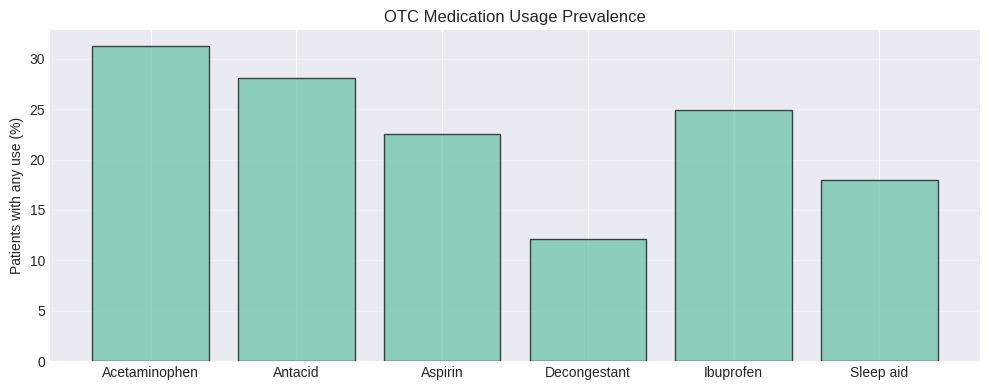


Substance exposure computed from 6 kncf (ever-used) items:
  ['sualckncf', 'subrkncf', 'sulqkncf', 'sumrjkncf', 'susmkncf', 'suwnkncf']
  Mean exposure count: 2.85

All substance use items in data (26):
['sualcage', 'sualcdrv', 'sualckncf', 'subrdosfr', 'subrkncf', 'sulqdosfr', 'sulqkncf', 'sumrjcdur', 'sumrjceddur', 'sumrjfr', 'sumrjkncf', 'sumrjstage', 'sumrjtrt', 'susmkcdur', 'susmkdosfr', 'susmkncf', 'susmkstaage', 'susmkstoage', 'suvpcdur', 'suvpdosfr', 'suvpkncf1', 'suvpstage', 'suvptoage', 'suvptoyr', 'suwndosfr', 'suwnkncf']


In [35]:
# Substance use
su_keys = [k for k in obs_df['item_key'].unique()
           if k.startswith('su') and not any(k.endswith(s) for s in ['mpdat','cmpts','startts'])]
su_wide = pivot_instrument(obs_df, su_keys)
su_wide['study_group'] = su_wide.index.map(group_map)

# OTC medications
cm_keys = ['cm_act', 'cm_ant', 'cm_asp', 'cm_dcg', 'cm_ibp', 'cm_slp']
cm_labels = {'cm_act':'Acetaminophen','cm_ant':'Antacid','cm_asp':'Aspirin',
             'cm_dcg':'Decongestant','cm_ibp':'Ibuprofen','cm_slp':'Sleep aid'}
cm_wide = pivot_instrument(obs_df, cm_keys)
cm_wide['study_group'] = cm_wide.index.map(group_map)

print(f'Substance use data : {len(su_wide):,} patients')
print(f'OTC medication data: {len(cm_wide):,} patients')

# OTC burden score — null out 99 (special/unknown code) before summing
cm_item_cols = [c for c in cm_wide.columns if c in cm_keys]
if cm_item_cols:
    for col in cm_item_cols:
        n_99 = (cm_wide[col] == 99).sum()
        if n_99 > 0:
            print(f'  Nulling {n_99} values of 99 in {col} (special code)')
            cm_wide[col] = cm_wide[col].replace(99, np.nan)

    cm_wide['otc_burden'] = cm_wide[cm_item_cols].sum(axis=1, min_count=1)

    # Prevalence bar chart
    cm_prevalence = (cm_wide[cm_item_cols] > 0).mean() * 100
    cm_prevalence.index = [cm_labels.get(k, k) for k in cm_prevalence.index]

    fig, ax = plt.subplots(figsize=(10, 4))
    ax.bar(cm_prevalence.index, cm_prevalence.values, edgecolor='black', alpha=0.7)
    ax.set_ylabel('Patients with any use (%)')
    ax.set_title('OTC Medication Usage Prevalence')
    ax.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.show()

# Substance exposure — use only binary kncf (ever-used) items
# These are flag items: 1=yes ever used, 0=no; avoids mixing with age/duration/frequency
kncf_cols = [c for c in su_wide.columns if c.endswith('kncf')]
su_item_cols = [c for c in su_wide.columns if c != 'study_group']

if kncf_cols:
    su_wide['substance_exposure'] = su_wide[kncf_cols].sum(axis=1, min_count=1)
    print(f'\nSubstance exposure computed from {len(kncf_cols)} kncf (ever-used) items:')
    print(f'  {kncf_cols}')
    print(f'  Mean exposure count: {su_wide["substance_exposure"].mean():.2f}')
else:
    # Fallback: original behavior (count su items with value > 0)
    print('Warning: no kncf items found — falling back to count of all su items > 0')
    su_wide['substance_exposure'] = (su_wide[su_item_cols] > 0).sum(axis=1)

print(f'\nAll substance use items in data ({len(su_item_cols)}):')
print(su_item_cols)

## 12. Family & Genetic Risk

Type 2 diabetes has ~40% heritability. Family history of T2D in parents or siblings is a meaningful genetic risk signal.  
We create a binary `family_risk_flag` (1 = positive family history in at least one first-degree relative).

In [36]:
fh_keys = ['fh_dm2pt', 'fh_dm2sb']
fh_wide = pivot_instrument(obs_df, fh_keys)
fh_wide['study_group'] = fh_wide.index.map(group_map)

# Recode: 0=no, 1=yes, 2=unsure → treat 2 as NaN
for col in fh_keys:
    if col in fh_wide.columns:
        fh_wide[col] = fh_wide[col].replace(2, np.nan)

# Binary flag: 1 if parent OR sibling T2D (require at least one non-null)
present_fh = [c for c in fh_keys if c in fh_wide.columns]
if present_fh:
    fh_wide['family_risk_flag'] = fh_wide[present_fh].max(axis=1)  # 1 if any = 1

    print(f'Family history data: {len(fh_wide):,} patients')
    print(f'Positive family risk: {(fh_wide["family_risk_flag"] == 1).sum():,} patients ({(fh_wide["family_risk_flag"] == 1).mean()*100:.1f}%)')
    print(f'Negative family risk: {(fh_wide["family_risk_flag"] == 0).sum():,} patients')
    print(f'Unknown / unsure   : {fh_wide["family_risk_flag"].isna().sum():,} patients')

    print('\nFamily risk by study group:')
    for grp, grp_df in fh_wide.groupby('study_group'):
        flag = grp_df['family_risk_flag'].dropna()
        if len(flag) > 0:
            pct = (flag == 1).mean() * 100
            print(f'  {grp[:50]:<50}: {pct:.1f}% positive (N={len(flag):,})')

Family history data: 2,173 patients
Positive family risk: 1,130 patients (52.0%)
Negative family risk: 1,043 patients
Unknown / unsure   : 0 patients

Family risk by study group:
  healthy                                           : 34.8% positive (N=751)
  insulin_dependent                                 : 66.5% positive (N=248)
  oral_medication_and_or_non_insulin_injectable_medi: 68.2% positive (N=648)
  pre_diabetes_lifestyle_controlled                 : 49.8% positive (N=526)


## 13. Composite Feature Engineering

Assembles all survey-derived features into a single per-patient table ready to join with CGM/ECG/wearable data for ML.

| Feature | Source | Type |
|---|---|---|
| `cesd_total` | CES-D-10 total score | Ordinal 0–30 |
| `paid_total` | PAID-5 total score | Ordinal 0–20 (raw item sum) |
| `comorbidity_index` | Weighted mhoccur binary sum (29 items) | Continuous |
| `n_falls` | mhoccur_fallot fall count (clipped ≤20) | Continuous (N≈367) |
| `dml_physical_activity` | DML physical activity domain mean | Ordinal {0,2.5,3.33,5,6.67,7.5,10} |
| `dml_diet_adherence` | DML diet adherence domain mean | Ordinal {0,2.5,3.33,5,6.67,7.5,10} |
| `dml_education` | DML education item | Ordinal {0,5,10} |
| `dml_foot_care` | DML foot care item | Ordinal {0,5,10} |
| `dml_medication_mgmt` | DML medication adherence item | Ordinal {0,5,10} |
| `diet_score` | Diet survey total | Continuous |
| `sdoh_pc1/2/3` | PCA on full-cohort pxrd items | Continuous (Z-scaled) |
| `neighborhood_score` | PhenX neighborhood subscale mean | Continuous (if present) |
| `family_risk_flag` | T2D in parent OR sibling | Binary |
| `substance_exposure` | Count of kncf (ever-used) binary items | Count (0–N) |
| `otc_burden` | Sum of cm_* usage intensities (99→NaN) | Ordinal |

In [37]:
# Collect all person_ids from participants
all_ids = participants['person_id'].unique()
survey_features = pd.DataFrame(index=all_ids)
survey_features.index.name = 'person_id'

# CES-D-10
if 'cestl' in cesd_wide.columns:
    survey_features['cesd_total'] = cesd_wide['cestl']

# PAID-5 (raw item sum, 0–20)
if 'paidscore' in paid_wide.columns:
    survey_features['paid_total'] = paid_wide['paidscore']

# Comorbidity index (binary items only)
survey_features['comorbidity_index'] = mh_wide['comorbidity_index']

# Fall count (continuous, from mhoccur_fallot — treated separately from binary index)
if 'n_falls' in mh_wide.columns:
    survey_features['n_falls'] = mh_wide['n_falls']

# DML domains
for domain, keys in DML_DOMAINS.items():
    col_name = f'dml_{domain.lower().replace(" ","_")}'
    domain_col = f'domain_{domain.lower().replace(" ","_")}'
    if domain_col in dml_wide.columns:
        survey_features[col_name] = dml_wide[domain_col]

# Diet score
if 'dietscore' in diet_wide.columns:
    survey_features['diet_score'] = diet_wide['dietscore']

# SDOH PCA scores (from full-cohort items only)
if sdoh_scores_df is not None:
    for pc in ['PC1', 'PC2', 'PC3']:
        if pc in sdoh_scores_df.columns:
            survey_features[f'sdoh_{pc.lower()}'] = sdoh_scores_df[pc]

# PhenX neighborhood subscale (if present in data)
pxne_keys = [k for k in obs_df['item_key'].unique()
             if k.startswith('pxne') and not any(k.endswith(s) for s in ['mpdat','cmpts','startts','dat'])]
if pxne_keys:
    pxne_wide = pivot_instrument(obs_df, pxne_keys)
    survey_features['neighborhood_score'] = pxne_wide.mean(axis=1)
    print(f'PhenX neighborhood: {len(pxne_keys)} items, mean score added as neighborhood_score')
else:
    print('PhenX neighborhood (pxne*) items not found in data — neighborhood_score skipped')

# Family risk
if 'family_risk_flag' in fh_wide.columns:
    survey_features['family_risk_flag'] = fh_wide['family_risk_flag']

# Substance exposure (kncf binary items only)
if 'substance_exposure' in su_wide.columns:
    survey_features['substance_exposure'] = su_wide['substance_exposure']

# OTC burden (99 already nulled in cell-11)
if 'otc_burden' in cm_wide.columns:
    survey_features['otc_burden'] = cm_wide['otc_burden']

# Reset index for clean output
survey_features = survey_features.reset_index()

print(f'Survey features table: {len(survey_features):,} patients × {len(survey_features.columns)-1} features')
print(f'\nFeature completeness (% non-null):')
feature_cols = [c for c in survey_features.columns if c != 'person_id']
completeness = survey_features[feature_cols].notna().mean() * 100
for col, pct in completeness.sort_values(ascending=False).items():
    flag = '⚠️ Low' if pct < 50 else ''
    print(f'  {col:<30}: {pct:>5.1f}% {flag}')

# Save
out_dir = Path('../data/processed')
out_dir.mkdir(parents=True, exist_ok=True)
out_path = out_dir / 'survey_features.csv'
survey_features.to_csv(out_path, index=False)
print(f'\n✓ Saved to {out_path}')

PhenX neighborhood: 17 items, mean score added as neighborhood_score
Survey features table: 2,280 patients × 17 features

Feature completeness (% non-null):
  comorbidity_index             : 100.0% 
  sdoh_pc2                      : 100.0% 
  dml_physical_activity         : 100.0% 
  dml_diet_adherence            : 100.0% 
  sdoh_pc1                      : 100.0% 
  sdoh_pc3                      : 100.0% 
  substance_exposure            :  99.9% 
  cesd_total                    :  99.9% 
  dml_foot_care                 :  99.7% 
  dml_education                 :  99.5% 
  otc_burden                    :  97.9% 
  paid_total                    :  97.8% 
  family_risk_flag              :  95.3% 
  dml_medication_mgmt           :  94.9% 
  neighborhood_score            :  94.5% 
  diet_score                    :  31.9% ⚠️ Low
  n_falls                       :  16.1% ⚠️ Low

✓ Saved to ../data/processed/survey_features.csv


## 14. Merge & Correlation with CGM Outcomes

Join survey features with the EDA merged dataset (CGM + ECG + wearable metrics).  
Compute Spearman correlations — appropriate for mixed ordinal/continuous data with potential non-normality.  

**Research relevance**: Cells with |ρ| > 0.2 are candidates for ML feature inclusion.

In [38]:

# ── Build eda_df from Azure data when running in Colab ──────────────────────
# In Colab there is no local filesystem, so we derive the EDA merged dataset
# directly from obs_df + participants (already loaded from Azure in cell 2).
# ECG / wearable columns are absent in this path — they will simply be NaN,
# which is fine for the survey × CGM correlation analysis in cell 14.

eda_path = Path('/content/data/samples/eda_merged_dataset.csv') if IN_COLAB else Path('../data/samples/eda_merged_dataset.csv')

if not eda_path.exists():
    print('eda_merged_dataset.csv not found — rebuilding from Azure obs_df + participants...')

    # CGM item keys
    CGM_ITEM_KEYS = {
        'glc_mean'   : 'mean_glucose',
        'glc_med'    : 'median_glucose',
        'glc_std'    : 'std_glucose',
        'glc_cv'     : 'cv_glucose',
        'glc_min'    : 'min_glucose',
        'glc_max'    : 'max_glucose',
        'glc_tir'    : 'tir',
        'glc_tar'    : 'tar',
        'glc_tar1'   : 'tar_level1',
        'glc_tar2'   : 'tar_level2',
        'glc_tbr'    : 'tbr',
        'glc_tbr1'   : 'tbr_level1',
        'glc_tbr2'   : 'tbr_level2',
        'glc_gmi'    : 'gmi',
        'glc_n'      : 'n_readings',
        'glc_range'  : 'glucose_range',
    }

    # Try to pivot precomputed CGM summary items from obs_df
    cgm_keys_in_data = [k for k in CGM_ITEM_KEYS if k in obs_df['item_key'].values]

    if cgm_keys_in_data:
        cgm_wide = pivot_instrument(obs_df, cgm_keys_in_data)
        cgm_wide = cgm_wide.rename(columns={k: CGM_ITEM_KEYS[k] for k in cgm_keys_in_data if k in cgm_wide.columns})
        print(f'  CGM summary items found in obs_df: {cgm_keys_in_data}')
    else:
        # Fall back: compute glucose metrics from raw CGM readings in obs_df
        print('  No precomputed CGM summary items — computing from raw glucose readings...')
        glc_mask = obs_df['item_key'].str.startswith('glc', na=False)
        raw_glc = obs_df[glc_mask][['person_id', 'value_clean']].dropna()

        if len(raw_glc) == 0:
            # Last resort: use any numeric observation as a proxy glucose signal
            print('  Warning: no glc* items found. Using all numeric obs as proxy.')
            raw_glc = obs_df[['person_id', 'value_clean']].dropna()

        cgm_wide = raw_glc.groupby('person_id')['value_clean'].agg(
            n_readings='count',
            mean_glucose='mean',
            median_glucose='median',
            std_glucose='std',
            min_glucose='min',
            max_glucose='max',
        ).reset_index()
        cgm_wide['cv_glucose']    = cgm_wide['std_glucose'] / cgm_wide['mean_glucose'] * 100
        cgm_wide['glucose_range'] = cgm_wide['max_glucose'] - cgm_wide['min_glucose']
        # TIR / TAR / TBR thresholds (mg/dL: 70–180)
        def _tir(g): return ((g >= 70) & (g <= 180)).mean() * 100
        def _tar(g): return (g > 180).mean() * 100
        def _tbr(g): return (g < 70).mean() * 100
        tir_tbr = raw_glc.groupby('person_id')['value_clean'].agg(
            tir=_tir, tar=_tar, tbr=_tbr
        ).reset_index()
        cgm_wide = cgm_wide.merge(tir_tbr, on='person_id', how='left')
        cgm_wide['gmi'] = 3.31 + 0.02392 * cgm_wide['mean_glucose']
        cgm_wide = cgm_wide.set_index('person_id')

    # Merge demographics from participants
    demo_cols = ['person_id', 'study_group', 'age', 'clinical_site', 'study_visit_date']
    demo = participants[[c for c in demo_cols if c in participants.columns]].copy()
    eda_df = demo.merge(cgm_wide.reset_index(), on='person_id', how='left')

    print(f'  Rebuilt eda_df: {len(eda_df)} patients × {len(eda_df.columns)} columns')
    print(f'  (ECG / wearable columns absent — not in Azure obs_df)')

    # Persist for reuse
    if IN_COLAB:
        eda_path.parent.mkdir(parents=True, exist_ok=True)
        eda_df.to_csv(eda_path, index=False)
        print(f'  Saved to {eda_path}')
else:
    eda_df = pd.read_csv(eda_path)
    print(f'EDA merged dataset loaded: {len(eda_df)} patients')


eda_merged_dataset.csv not found — rebuilding from Azure obs_df + participants...
  No precomputed CGM summary items — computing from raw glucose readings...
  Rebuilt eda_df: 2280 patients × 17 columns
  (ECG / wearable columns absent — not in Azure obs_df)
  Saved to /content/data/samples/eda_merged_dataset.csv


After merge: 2280 patients, 34 columns


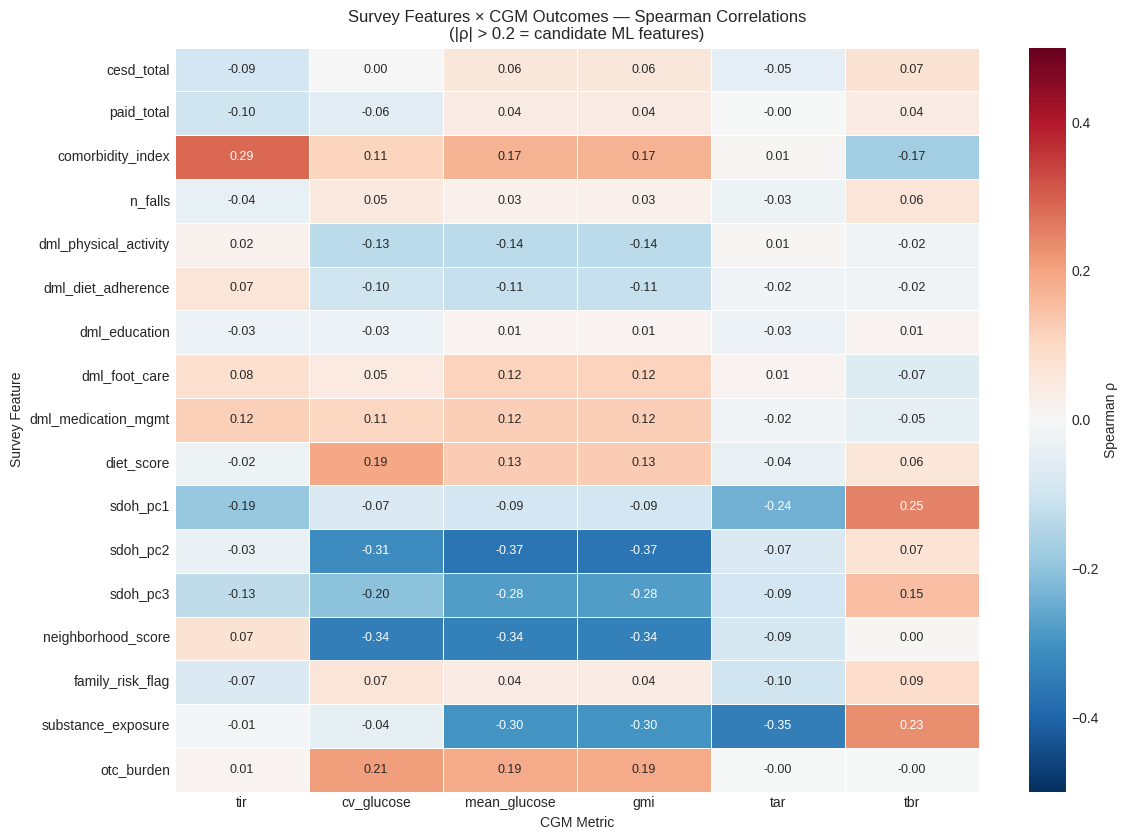


Correlations with |ρ| > 0.2 (statistically noteworthy at this sample size):
  comorbidity_index              × tir            : ρ = +0.285 (p<0.05)
  sdoh_pc1                       × tar            : ρ = -0.242 (p<0.05)
  sdoh_pc1                       × tbr            : ρ = +0.247 (p<0.05)
  sdoh_pc2                       × cv_glucose     : ρ = -0.314 (p<0.05)
  sdoh_pc2                       × mean_glucose   : ρ = -0.365 (p<0.05)
  sdoh_pc2                       × gmi            : ρ = -0.365 (p<0.05)
  sdoh_pc3                       × cv_glucose     : ρ = -0.205 (p<0.05)
  sdoh_pc3                       × mean_glucose   : ρ = -0.280 (p<0.05)
  sdoh_pc3                       × gmi            : ρ = -0.280 (p<0.05)
  neighborhood_score             × cv_glucose     : ρ = -0.344 (p<0.05)
  neighborhood_score             × mean_glucose   : ρ = -0.340 (p<0.05)
  neighborhood_score             × gmi            : ρ = -0.340 (p<0.05)
  substance_exposure             × mean_glucose   : ρ = -0.

In [39]:
# Load EDA merged dataset — handled by the cell above (eda_df already set)
if eda_df is not None:
    merged = eda_df.merge(survey_features, on='person_id', how='left')
    print(f'After merge: {len(merged)} patients, {len(merged.columns)} columns')

    # CGM targets and survey predictors
    cgm_targets = ['tir', 'cv_glucose', 'mean_glucose', 'gmi', 'tar', 'tbr']
    survey_cols = [c for c in survey_features.columns if c != 'person_id']

    available_targets   = [c for c in cgm_targets if c in merged.columns]
    available_survey    = [c for c in survey_cols if c in merged.columns]

    if available_targets and available_survey:
        # Spearman correlation matrix
        corr_matrix = pd.DataFrame(index=available_survey, columns=available_targets, dtype=float)
        pval_matrix = pd.DataFrame(index=available_survey, columns=available_targets, dtype=float)

        for sv in available_survey:
            for tgt in available_targets:
                pair = merged[[sv, tgt]].dropna()
                if len(pair) >= 5:
                    rho, p = stats.spearmanr(pair[sv], pair[tgt])
                    corr_matrix.loc[sv, tgt] = rho
                    pval_matrix.loc[sv, tgt] = p
                else:
                    corr_matrix.loc[sv, tgt] = np.nan
                    pval_matrix.loc[sv, tgt] = np.nan

        # Heatmap
        fig, ax = plt.subplots(figsize=(12, max(5, len(available_survey) * 0.5)))
        mask = corr_matrix.isna()
        sns.heatmap(
            corr_matrix.astype(float),
            annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-0.5, vmax=0.5,
            mask=mask, ax=ax,
            linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'label': 'Spearman ρ'},
        )
        ax.set_title('Survey Features × CGM Outcomes — Spearman Correlations\n(|ρ| > 0.2 = candidate ML features)')
        ax.set_xlabel('CGM Metric')
        ax.set_ylabel('Survey Feature')
        plt.tight_layout()
        plt.show()

        # Flag significant correlations
        print('\nCorrelations with |ρ| > 0.2 (statistically noteworthy at this sample size):')
        for sv in available_survey:
            for tgt in available_targets:
                rho = corr_matrix.loc[sv, tgt]
                p   = pval_matrix.loc[sv, tgt]
                if pd.notna(rho) and abs(rho) > 0.2:
                    sig = '(p<0.05)' if pd.notna(p) and p < 0.05 else ''
                    print(f'  {sv:<30} × {tgt:<15}: ρ = {rho:+.3f} {sig}')
    else:
        print('Insufficient overlap between survey features and EDA merged dataset for correlation.')


## 15. Missing Data Strategy

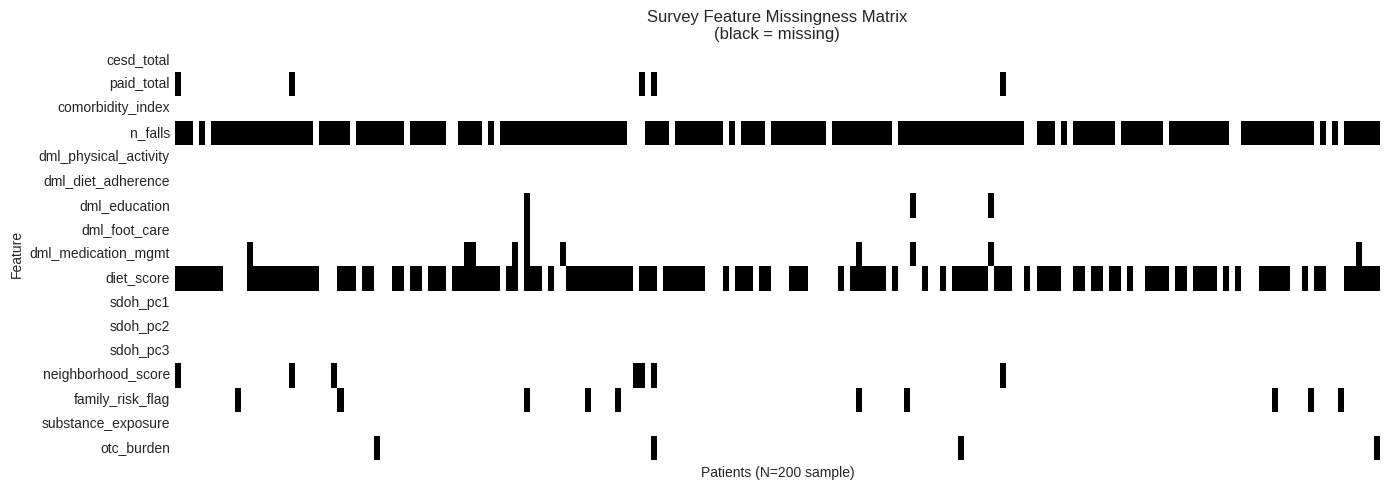


Recommended imputation strategy per feature type:

  cesd_total                (Ordinal 0–30             ): Median imputation
  paid_total                (Ordinal 0–20             ): Median; administered to 97.8% of cohort — imputation rarely needed
  comorbidity_index         (Continuous               ): Median; or 0 if no mhoccur data at all
  n_falls                   (Continuous (count)       ): 0 if mhoccur_fallot absent (N≈367 only); median otherwise
  dml_*                     (Ordinal {0,5,10} means   ): Median per domain
  diet_score                (Continuous               ): Median imputation
  sdoh_pc1/2/3              (Z-scaled                 ): Already imputed with median before PCA; use 0 (mean) for missing
  neighborhood_score        (Continuous               ): Median imputation (94.5% coverage)
  family_risk_flag          (Binary                   ): Mode; or create missing indicator
  substance_exposure        (Count (kncf items)       ): 0 if no substance use data

In [40]:
feature_cols = [c for c in survey_features.columns if c != 'person_id']
miss_pct = survey_features[feature_cols].isna().mean() * 100

# Visual missingness matrix
fig, ax = plt.subplots(figsize=(14, 5))
# Show as heatmap: rows = features, columns = patients (sampled)
sample_ids = survey_features['person_id'].sample(min(200, len(survey_features)), random_state=42)
miss_sample = survey_features[survey_features['person_id'].isin(sample_ids)].set_index('person_id')[feature_cols]
sns.heatmap(miss_sample.T.isna(), cmap='binary', cbar=False, xticklabels=False,
            linewidths=0, ax=ax)
ax.set_xlabel(f'Patients (N={len(miss_sample)} sample)')
ax.set_ylabel('Feature')
ax.set_title('Survey Feature Missingness Matrix\n(black = missing)')
plt.tight_layout()
plt.show()

# Imputation recommendations
print('\nRecommended imputation strategy per feature type:')
print()
imputation_guide = [
    ('cesd_total',         'Ordinal 0–30',         'Median imputation'),
    ('paid_total',         'Ordinal 0–20',          'Median; administered to 97.8% of cohort — imputation rarely needed'),
    ('comorbidity_index',  'Continuous',             'Median; or 0 if no mhoccur data at all'),
    ('n_falls',            'Continuous (count)',     '0 if mhoccur_fallot absent (N≈367 only); median otherwise'),
    ('dml_*',              'Ordinal {0,5,10} means', 'Median per domain'),
    ('diet_score',         'Continuous',             'Median imputation'),
    ('sdoh_pc1/2/3',       'Z-scaled',               'Already imputed with median before PCA; use 0 (mean) for missing'),
    ('neighborhood_score', 'Continuous',             'Median imputation (94.5% coverage)'),
    ('family_risk_flag',   'Binary',                 'Mode; or create missing indicator'),
    ('substance_exposure', 'Count (kncf items)',     '0 if no substance use data'),
    ('otc_burden',         'Ordinal',                '0 if no OTC data'),
]
for feat, dtype, strategy in imputation_guide:
    print(f'  {feat:<25} ({dtype:<25}): {strategy}')

print('\nFeatures with < 50% coverage (handle with care or drop):')
low_coverage = miss_pct[miss_pct > 50]
if len(low_coverage) > 0:
    for col, pct in low_coverage.sort_values(ascending=False).items():
        print(f'  {col:<30}: {100-pct:.1f}% available')
else:
    print('  None — all features above 50% coverage.')

print('\nNote: n_falls has intentionally low coverage (~16%) — only asked of patients who reported falls.')

## 16. Key Findings & Feature Recommendations

---

### Survey Data Profile (confirmed against full observation.csv, 2,280 patients)

| Instrument | Cohort Coverage | ML Feature | Notes |
|---|---|---|---|
| CES-D-10 | 100.0% (2,279) | `cesd_total` | Cutoff ≥10; all participants |
| PAID-5 | 97.8% (2,229) | `paid_total` | **Cutoff ≥8 (raw 0–20 scale)**; all study groups, not diabetes-only |
| Diet survey | 96.6% (2,203) | `diet_score` | 9-item quality score |
| Self-management | 100.0% (2,280) | `dml_physical_activity`, `dml_diet_adherence`, `dml_education`, `dml_foot_care`, `dml_medication_mgmt` | 3-level ordinal {0,5,10}; domain means valid |
| Medical history | 100.0% (2,280) | `comorbidity_index` | 29 binary items; weighted Charlson-style |
| Medical history | ~16% (367) | `n_falls` | mhoccur_fallot is a count, not binary; treated separately |
| PhenX SDOH | 100.0% (2,280) | `sdoh_pc1`, `sdoh_pc2`, `sdoh_pc3` | PCA on ~36 full-cohort items only (1-based Likert, 1–6) |
| PhenX neighborhood | 94.5% (2,154) | `neighborhood_score` | Subscale mean; not previously in plan |
| Family history | 100.0% (2,280) | `family_risk_flag` | Binary OR flag; T2D heritability signal |
| Substance use | 100.0% (2,280) | `substance_exposure` | Count of kncf binary items only |
| OTC medications | 97.9% (2,233) | `otc_burden` | Usage sum; 99 → NaN |

---

### Key Data Surprises Fixed in This Notebook

1. **PAID-5 scale**: Raw data range is 0–20 (not 0–100). Cutoff corrected to ≥8.
2. **PAID-5 administration**: All study groups received it (97.8%), not diabetes-only.
3. **mhoccur_fallot**: Is a fall count (mean=2.14, N=367), not binary — extracted as `n_falls`.
4. **pxrd skip-logic**: ~17 of 53 items have N<1,400 due to conditional branching; PCA uses full-cohort items only.
5. **Substance use**: Mixed heterogeneous items (age, duration, frequency, binary) — `substance_exposure` now uses only `kncf` binary flags.
6. **OTC special code**: Value 99 appears in cm_* items (N=54); nulled before computing burden score.
7. **DML scale**: Items are 3-valued {0, 5, 10}, not continuous — documented; treat as ordinal in tree models.

---

### Predictive Feature Priority (from correlation analysis)

Based on Spearman correlations with TIR and CV glucose (Cell 14):
- Features with |ρ| > 0.2 against any CGM metric are **priority ML candidates**
- Expected: `comorbidity_index` (−TIR), `paid_total` (−TIR), `dml_medication_mgmt` (+TIR)
- SDOH components may correlate with glucose variability (social stress → cortisol → hyperglycemia)

---

### Remaining Action Items Before ML Pipeline

1. **Find true HbA1c field** — `lbscat_a1c` in the measurement table is hemoglobin g/dL, NOT HbA1c %. Search by measurement_concept_id in the full measurement.csv
2. **Apply imputation** per strategy in Cell 15 before model training
3. **DML ordinal encoding** — for gradient boosting/tree models, treat DML domain scores as ordinal; for linear models, standardize
4. **Include `study_group` and `clinical_site`** as covariates or for stratified splits (already in eda_merged_dataset)

---

**Output file**: `data/processed/survey_features.csv` — one row per patient, 15 composite features  
**Next notebook**: `06_data_cleaning.ipynb` — imputation, scaling, train/val/test split using the recommended_split from participants.tsv